In [ ]:
import numpy as np
import gudhi as gd
import gudhi.representations as gdr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

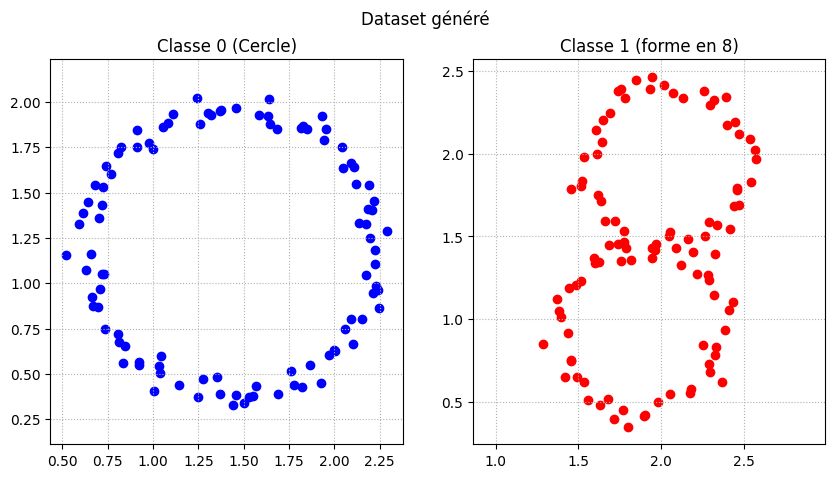

In [2]:
# données : cercle vs Ffgure en 8
# contraintes : rotations ET translations aléatoires

def generate_figure_8(n_points, noise=0.05):
    n1 = n_points // 2
    n2 = n_points - n1
    t1 = np.linspace(0, 2*np.pi, n1, endpoint=False)
    c1 = np.column_stack((0.5 * np.cos(t1) - 0.5, 0.5 * np.sin(t1)))
    t2 = np.linspace(0, 2*np.pi, n2, endpoint=False)
    c2 = np.column_stack((0.5 * np.cos(t2) + 0.5, 0.5 * np.sin(t2)))
    X = np.vstack((c1, c2)) + np.random.normal(0, noise, (n_points, 2))
    return X

def generate_circle(n_points, noise=0.05):
    t = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    X = np.column_stack((0.8 * np.cos(t), 0.8 * np.sin(t))) 
    X += np.random.normal(0, noise, X.shape)
    return X

#transformations
def apply_random_transform(X):
    theta = np.random.uniform(0, 2*np.pi)
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    X = X @ rot
    trans = np.random.uniform(-3, 3, 2)
    X = X + trans
    return X

N_SAMPLES = 200
X_clouds = []
X_flat = []
y_labels = []

np.random.seed(42)

for i in range(N_SAMPLES):
    if i < N_SAMPLES // 2:
        cloud = generate_circle(100)
        label = 0
    else:
        cloud = generate_figure_8(100)
        label = 1
        
    cloud = apply_random_transform(cloud)
    
    X_clouds.append(cloud)
    X_flat.append(cloud.flatten())
    y_labels.append(label)

X_flat = np.array(X_flat)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
idx1, idx2 = 0, -1
axes[0].scatter(X_clouds[idx1][:,0], X_clouds[idx1][:,1], c='blue', label='Cercle')
axes[0].set_title("Classe 0 (Cercle)")
axes[0].grid(True, linestyle=':')
axes[0].axis('equal')

axes[1].scatter(X_clouds[idx2][:,0], X_clouds[idx2][:,1], c='red', label='Figure 8')
axes[1].set_title("Classe 1 (forme en 8)")
axes[1].grid(True, linestyle=':')
axes[1].axis('equal')
plt.suptitle("Dataset généré")
plt.show()

In [3]:
# baseline (RF sur coords applaties)
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_labels, test_size=0.3, random_state=42)
clf_base = RandomForestClassifier(n_estimators=100, random_state=42)
clf_base.fit(X_train, y_train)
acc_base = accuracy_score(y_test, clf_base.predict(X_test))
print(f"Précision Baseline (Coordonnées) : {acc_base*100:.1f}%")


# pipeline TDA
diagrams = []
for cloud in X_clouds:
    st = gd.AlphaComplex(points=cloud).create_simplex_tree()
    st.compute_persistence()
    diag = st.persistence_intervals_in_dimension(1)
    clean = [(p[0], 2.0) if p[1] == float('inf') else p for p in diag]
    diagrams.append(np.array(clean) if len(clean) > 0 else np.empty((0, 2)))

# vectorisation (landscapes)
landscape = gdr.Landscape(num_landscapes=2, resolution=100, sample_range=[0, 2.0])
X_tda = landscape.fit_transform(diagrams)

# classification TDA
X_train_tda, X_test_tda, y_train_tda, y_test_tda = train_test_split(X_tda, y_labels, test_size=0.3, random_state=42)
clf_tda = RandomForestClassifier(n_estimators=100, random_state=42)
clf_tda.fit(X_train_tda, y_train_tda)
acc_tda = accuracy_score(y_test_tda, clf_tda.predict(X_test_tda))
print(f"Précision TDA (Topologie) : {acc_tda*100:.1f}%")

Précision Baseline (Coordonnées) : 56.7%
Précision TDA (Topologie) : 100.0%


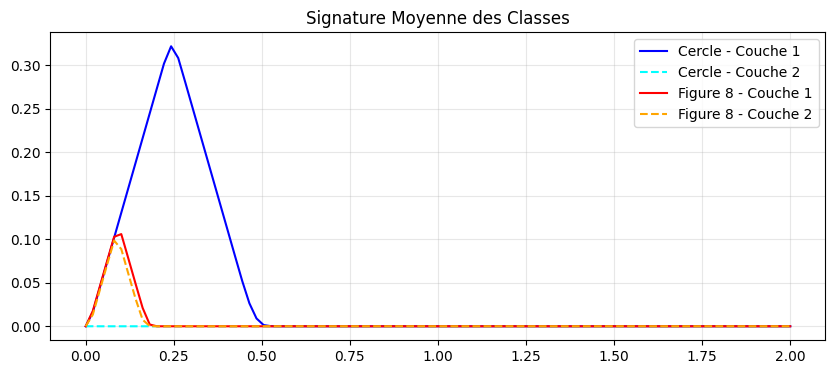

In [5]:
# Landscapes moyens
mean_0 = np.mean([x for x, y in zip(X_tda, y_labels) if y==0], axis=0)
mean_1 = np.mean([x for x, y in zip(X_tda, y_labels) if y==1], axis=0)

plt.figure(figsize=(10, 4))
x_ax = np.linspace(0, 2.0, 100)
plt.plot(x_ax, mean_0[:100], c='blue', label='Cercle - Couche 1')
plt.plot(x_ax, mean_0[100:], c='cyan', linestyle='--', label='Cercle - Couche 2')

plt.plot(x_ax, mean_1[:100], c='red', label='Figure 8 - Couche 1')
plt.plot(x_ax, mean_1[100:], c='orange', linestyle='--', label='Figure 8 - Couche 2')

plt.title("Signature Moyenne des Classes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

plt.figure(figsize=(6, 5))
plt.bar(['Baseline\n(Echec)', 'TDA\n(Succès)'], [acc_base, acc_tda], color=['gray', 'green'])
plt.ylabel('Précision')
plt.title(f'Comparaison Finale\nGain TDA : +{(acc_tda-acc_base)*100:.1f}%')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate([acc_base, acc_tda]):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.show()

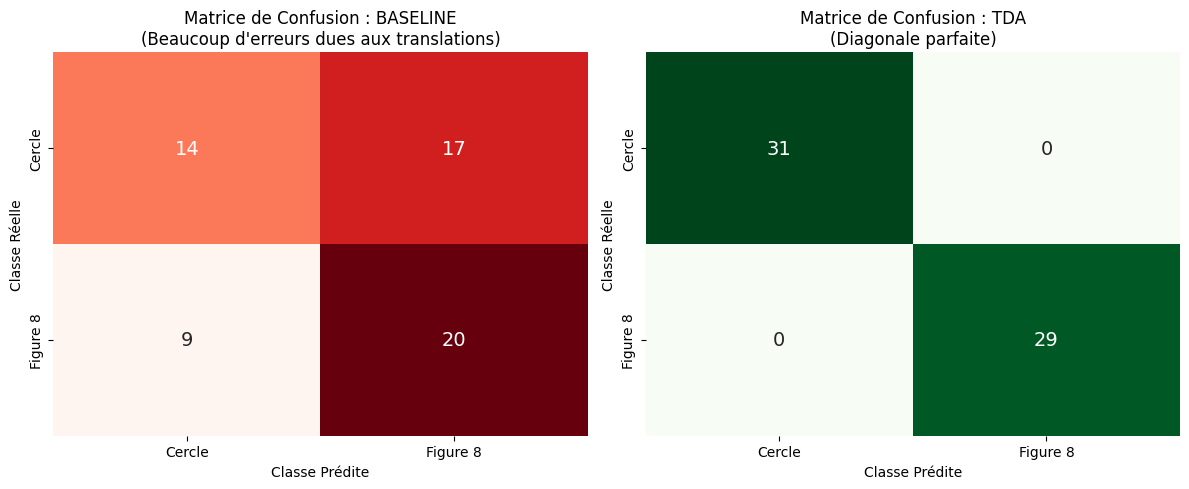

In [ ]:
#Matrices de Confusion
# calcul des prédictions
y_pred_base = clf_base.predict(X_test)
y_pred_tda = clf_tda.predict(X_test_tda)

# calcul des matrices
cm_base = confusion_matrix(y_test, y_pred_base)
cm_tda = confusion_matrix(y_test_tda, y_pred_tda)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes = ['Cercle', 'Figure 8']

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0],
            xticklabels=classes, yticklabels=classes, annot_kws={"size": 14})
axes[0].set_title(f"Matrice de Confusion : BASELINE\n(Beaucoup d'erreurs dues aux translations)")
axes[0].set_xlabel("Classe Prédite")
axes[0].set_ylabel("Classe Réelle")

# Matrice TDA
sns.heatmap(cm_tda, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=classes, yticklabels=classes, annot_kws={"size": 14})
axes[1].set_title(f"Matrice de Confusion : TDA\n(Diagonale parfaite)")
axes[1].set_xlabel("Classe Prédite")
axes[1].set_ylabel("Classe Réelle")

plt.tight_layout()
plt.show()